# IY021 – SVM vs Catch22+SVM on Experimental GFP Time Series

**Goal:** Classify GFP steady-state time series by glucose environment using two approaches:
1. **Raw SVM (RBF)** – raw time series directly as features
2. **Catch22 + SVM (RBF)** – 22 canonical time-series features as input to SVM

**Data:** `EXP-25-IY013/transformed_exp_time_series_data/`

---

### TF structure of the experiments

Each experiment contains multiple yeast strains ("groups"), each expressing **Msn2-mCherry** (always the GFP channel) alongside a strain-specific **GFP-TF**. Classifications are only meaningful when comparing the **same strain** under different glucose conditions.

| Experiment | Glucose | group 1344 (Cat8-GFP) | group 1346 (Nrg1-GFP) | group 1347 (Rtg1-GFP) | Other groups |
|---|---|---|---|---|---|
| 19316 | **2%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 19554 | 0.01% | — | — | — | 900=Mig1/Msn2, 756/903=unknown |
| 19566 | **0.1%** | ⚠️ TF uncertain | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 20213 | **0.01%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |

**Exclusions (with reason):**
- **19554 entirely**: Mig1 strain (group 900) is not present in other experiments; groups 756/903 have unidentified TFs
- **19566 / group 1344**: TF identity ambiguous (absent from OMERO metadata for this experiment)

**Included for 3-way classification (2% vs 0.1% vs 0.01%):**  
Groups **1346 (Nrg1)** and **1347 (Rtg1)** — the only strains present across all 3 glucose conditions.

In [1]:
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycatch22
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

# wela lives in a separate env (requires numpy<2, incompatible with stochastic_sim).
# Add both editable-install source roots so wela is importable without touching
# this environment's numpy.
sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

np.random.seed(42)

DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/transformed_exp_time_series_data_v2")

## 1. Load Data & Assign Environment Labels

In [2]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}

print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))
    else:
        print("  (no TF metadata)")

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [3]:
FILE_REGISTRY = {
    # --- 2% glucose (label 0) ---
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series":
        (0, "2%",   "Nrg1", "GFP"),
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series":
        (0, "2%",   "Rtg1", "GFP"),
    # --- 0.1% glucose (label 1) ---
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series":
        (1, "0.1%", "Nrg1", "GFP"),
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series":
        (1, "0.1%", "Rtg1", "GFP"),
    # --- 0.01% glucose (label 2) ---
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series":
        (2, "0.01%", "Nrg1", "GFP"),
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series":
        (2, "0.01%", "Rtg1", "GFP"),
}
# Exclusions (with reason):
#   19554 entirely  – Mig1-GFP (group 900) not comparable; groups 756/903 TF unknown
#   19566/group1344 – TF identity ambiguous (absent from OMERO metadata)
#   Cat8 (group1344 in 19316/20213) – only present in 2 of 3 conditions; excluded for balance

label_names = {0: "2% glucose", 1: "0.1% glucose", 2: "0.01% glucose"}
META_COLS   = ["id", "group", "experiment"]

all_X, all_y, all_strain = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem
    if stem not in FILE_REGISTRY:
        continue
    glucose_label, glucose_pct, gfp_tf, channel = FILE_REGISTRY[stem]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_X.append(ts)
    all_y.extend([glucose_label] * len(ts))
    all_strain.extend([gfp_tf] * len(ts))
    print(f"  Loaded: {gfp_tf} (GFP) @ {glucose_pct} glc  "
          f"({ts.shape[0]} cells × {ts.shape[1]} tp)")

# Files have different numbers of timepoints — truncate to the shortest
min_tp = min(ts.shape[1] for ts in all_X)
print(f"\nTruncating all series to {min_tp} timepoints (shortest file)")
all_X = [ts[:, :min_tp] for ts in all_X]

X_raw   = np.vstack(all_X)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    mask = y == lbl
    strain_counts = {s: int(np.sum(strains[mask] == s)) for s in np.unique(strains[mask])}
    print(f"  {lbl}: {name:15s} → {mask.sum():4d} cells  {strain_counts}")

  Loaded: Nrg1 (GFP) @ 2% glc  (84 cells × 232 tp)
  Loaded: Rtg1 (GFP) @ 2% glc  (78 cells × 146 tp)
  Loaded: Nrg1 (GFP) @ 0.1% glc  (231 cells × 219 tp)
  Loaded: Rtg1 (GFP) @ 0.1% glc  (200 cells × 80 tp)
  Loaded: Nrg1 (GFP) @ 0.01% glc  (231 cells × 104 tp)
  Loaded: Rtg1 (GFP) @ 0.01% glc  (275 cells × 165 tp)

Truncating all series to 80 timepoints (shortest file)
Dataset: 1099 cells × 80 timepoints
  0: 2% glucose      →  162 cells  {np.str_('Nrg1'): 84, np.str_('Rtg1'): 78}
  1: 0.1% glucose    →  431 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 200}
  2: 0.01% glucose   →  506 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 275}


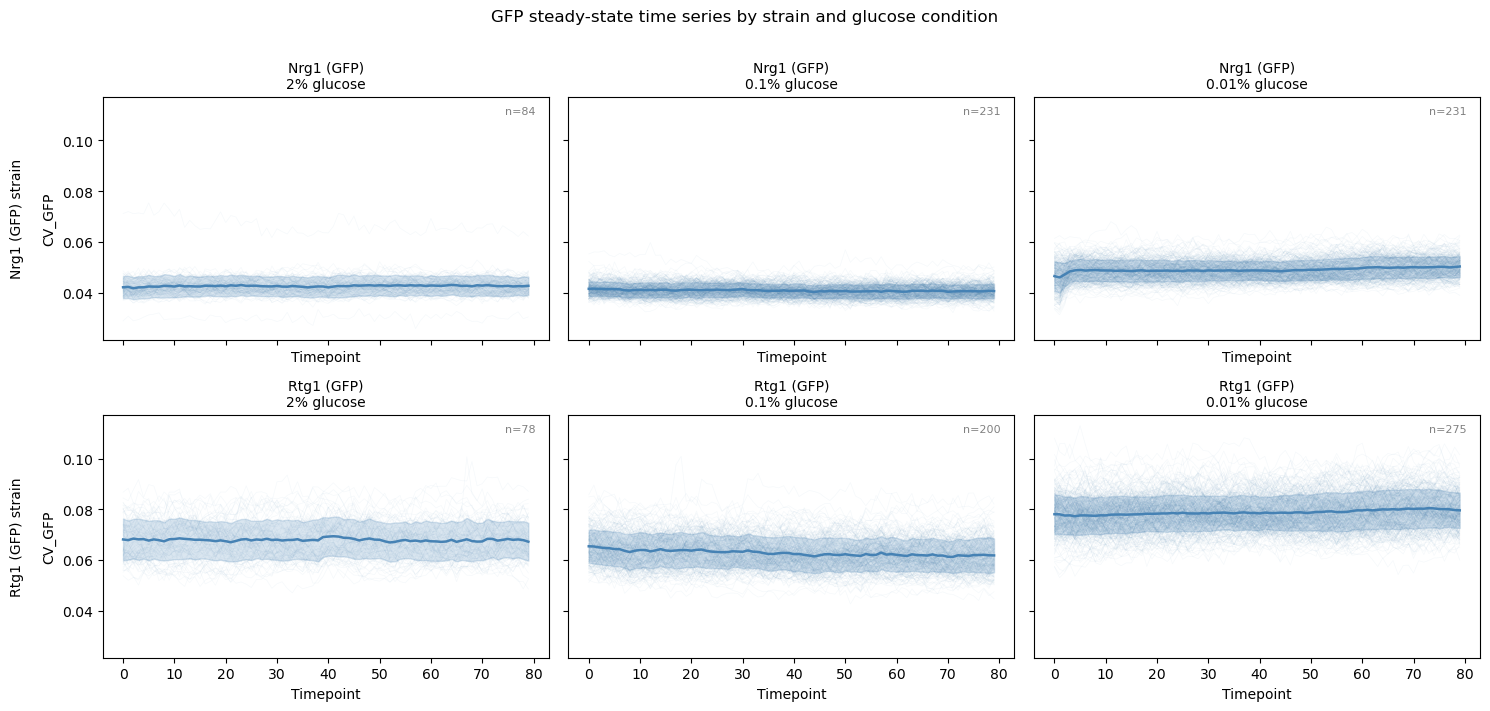

In [4]:

# --- Time series overview: each TF under each glucose condition ---
# Rows = strain context (GFP-tagged TF co-expressed alongside Msn2-mCherry)
# Cols = glucose condition
# All traces show Msn2 (mCherry) — the only channel in these CSVs

tfs        = ["Nrg1", "Rtg1"]
conditions = sorted(label_names.keys())   # 0, 1, 2  →  2%, 0.1%, 0.01%
n_tp       = X_raw.shape[1]
t_axis     = np.arange(n_tp)

fig, axes = plt.subplots(len(tfs), len(conditions),
                         figsize=(5 * len(conditions), 3.5 * len(tfs)),
                         sharey=True, sharex=True)

for row, tf in enumerate(tfs):
    for col, lbl in enumerate(conditions):
        ax    = axes[row][col]
        mask  = (y == lbl) & (strains == tf)
        X_sub = X_raw[mask]

        for trace in X_sub:
            ax.plot(t_axis, trace, color="steelblue", alpha=0.05, linewidth=0.5)

        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            std  = np.nanstd(X_sub, axis=0)
            ax.plot(t_axis, mean, color="steelblue", linewidth=1.8)
            ax.fill_between(t_axis, mean - std, mean + std,
                            color="steelblue", alpha=0.2)

        ax.set_title(f"{tf} (GFP)\n{label_names[lbl]}", fontsize=10)
        ax.set_xlabel("Timepoint")
        if col == 0:
            ax.set_ylabel(f"{tf} (GFP) strain\n\nCV_GFP")
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")

fig.suptitle("GFP steady-state time series by strain and glucose condition",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 2. Preprocessing: NaN Handling, Balancing & Train/Test Split

In [5]:
def fill_nans(X):
    """Interpolate NaNs per row; fallback to column median."""
    X = X.copy()
    for i in range(X.shape[0]):
        row = pd.Series(X[i])
        row = row.interpolate().ffill().bfill()
        X[i] = row.values
    # Any remaining NaNs → column median
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    return X

X_clean = fill_nans(X_raw)
print(f"NaN remaining after fill: {np.isnan(X_clean).sum()}")

# --- Balance classes by subsampling to the minority class size ---
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Minority class count: {min_count} → subsampling all classes to this size")

balanced_idx = []
for lbl in sorted(label_names):
    idx = np.where(y == lbl)[0]
    chosen = np.random.choice(idx, size=min_count, replace=False)
    balanced_idx.extend(chosen)

balanced_idx = np.array(balanced_idx)
X_bal = X_clean[balanced_idx]
y_bal = y[balanced_idx]

print(f"\nBalanced dataset: {X_bal.shape[0]} cells × {X_bal.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y_bal == lbl)}")

# --- Train / Test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

NaN remaining after fill: 0
Minority class count: 162 → subsampling all classes to this size

Balanced dataset: 486 cells × 80 timepoints
  Label 0 (2% glucose): 162
  Label 1 (0.1% glucose): 162
  Label 2 (0.01% glucose): 162

Train: 388  |  Test: 98
Train class counts: [130 129 129]
Test  class counts: [32 33 33]


## 3. Raw SVM (RBF) – Time Series as Features

In [6]:
print("=== Raw SVM (RBF) ===")

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"Raw SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=[label_names[i] for i in sorted(label_names)]))

=== Raw SVM (RBF) ===
Raw SVM Accuracy: 0.7041

               precision    recall  f1-score   support

   2% glucose       0.64      0.44      0.52        32
 0.1% glucose       0.64      0.82      0.72        33
0.01% glucose       0.82      0.85      0.84        33

     accuracy                           0.70        98
    macro avg       0.70      0.70      0.69        98
 weighted avg       0.70      0.70      0.69        98



## 4. Catch22 + SVM (RBF) – Hand-crafted Features

In [7]:
def extract_catch22(X, desc=""):
    """Extract 22 canonical time-series features for each row of X."""
    rows = []
    for ts in tqdm(X, desc=desc, leave=False):
        out = pycatch22.catch22_all(ts.tolist())
        rows.append(dict(zip(out["names"], out["values"])))
    df_feats = pd.DataFrame(rows)
    # Replace inf / -inf with NaN then fill with column median
    df_feats = df_feats.replace([np.inf, -np.inf], np.nan)
    df_feats = df_feats.fillna(df_feats.median())
    return df_feats

print("Extracting Catch22 features (train)...")
X_train_c22 = extract_catch22(X_train, desc="Train")
print("Extracting Catch22 features (test)...")
X_test_c22  = extract_catch22(X_test,  desc="Test")

print(f"\nCatch22 feature matrix: {X_train_c22.shape[1]} features")

# --- Catch22 + SVM ---
print("\n=== Catch22 + SVM (RBF) ===")

c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])

c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"Catch22 + SVM Accuracy: {c22_acc:.4f}")
print()
print(classification_report(y_test, y_pred_c22, target_names=[label_names[i] for i in sorted(label_names)]))

Extracting Catch22 features (train)...


Extracting Catch22 features (test)...



Catch22 feature matrix: 22 features

=== Catch22 + SVM (RBF) ===


Catch22 + SVM Accuracy: 0.5204

               precision    recall  f1-score   support

   2% glucose       0.48      0.41      0.44        32
 0.1% glucose       0.59      0.58      0.58        33
0.01% glucose       0.49      0.58      0.53        33

     accuracy                           0.52        98
    macro avg       0.52      0.52      0.52        98
 weighted avg       0.52      0.52      0.52        98



## 5. Results Comparison

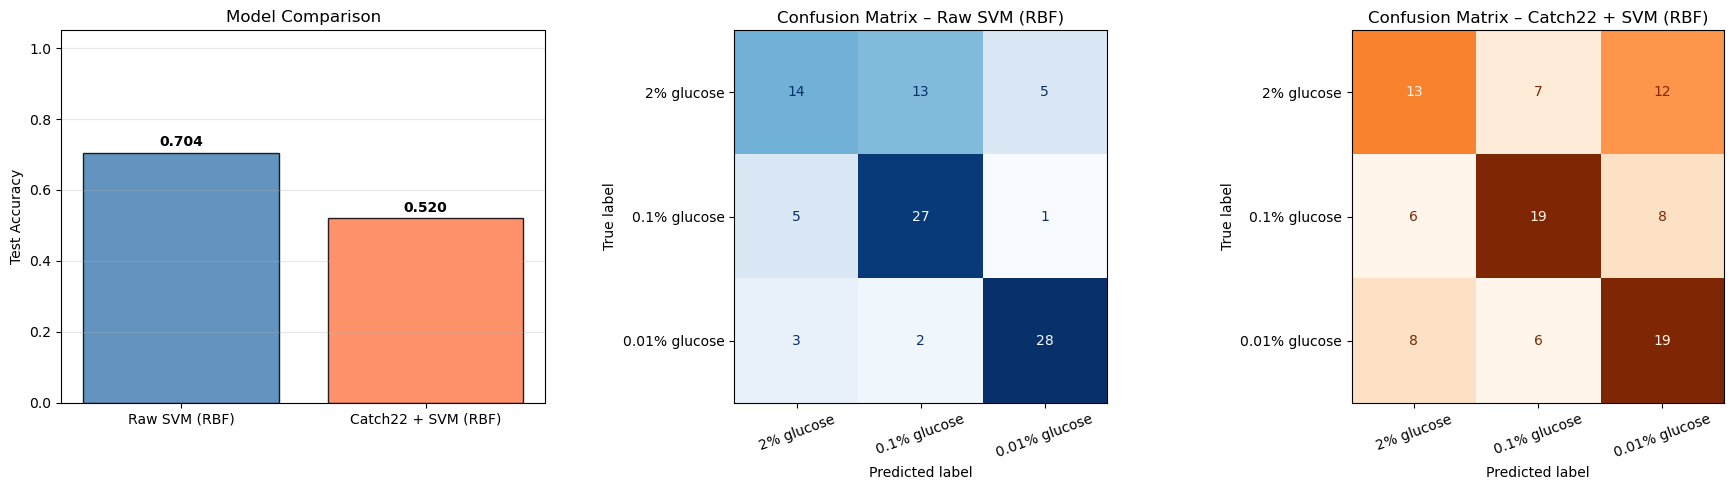


=== Summary ===
  Raw SVM (RBF)       : 0.7041
  Catch22 + SVM (RBF) : 0.5204
  Winner: Raw SVM (+0.1837)


In [8]:
class_names = [label_names[i] for i in sorted(label_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Accuracy bar chart ---
models  = ["Raw SVM (RBF)", "Catch22 + SVM (RBF)"]
accs    = [svm_acc, c22_acc]
colors  = ["steelblue", "coral"]

bars = axes[0].bar(models, accs, color=colors, alpha=0.85, edgecolor="black")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Model Comparison")
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", va="bottom", fontweight="bold")

# --- Confusion matrix: Raw SVM ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=class_names,
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
)
axes[1].set_title("Confusion Matrix – Raw SVM (RBF)")
axes[1].tick_params(axis="x", rotation=20)

# --- Confusion matrix: Catch22 + SVM ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c22,
    display_labels=class_names,
    ax=axes[2],
    colorbar=False,
    cmap="Oranges",
)
axes[2].set_title("Confusion Matrix – Catch22 + SVM (RBF)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("IY021_svm_vs_catch22_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Summary ===")
print(f"  Raw SVM (RBF)       : {svm_acc:.4f}")
print(f"  Catch22 + SVM (RBF) : {c22_acc:.4f}")
winner = "Raw SVM" if svm_acc >= c22_acc else "Catch22 + SVM"
print(f"  Winner: {winner} (+{abs(svm_acc - c22_acc):.4f})")